Electrostatic simulation of a Xmon and extracting Hamiltonian parameters with LOM analysis. 

The layout was built and meshed in ```build_and_mesh_transmons.ipynb```.

In [1]:
from pypalace import Config, Simulation,mesh
from pypalace.builder import Model, Domains, Boundaries, Solver
from pypalace.palace_env import get_palace_executable

Define paths

In [2]:
''' path to Palace executable ''' 
# enter path to Palace exec
#path_to_palace = "path/to/AWSPalace/install/bin/palace-<your architecture>.bin" 

# or if you have palace already added to path
path_to_palace = get_palace_executable()

''' path to mesh files / where we will save generated config files '''
mesh_dir = "mesh/"
config_dir = "config/"

''' path to mesh file + name of config file we will generate in pyPalace'''
xmon_meshfile = mesh_dir + "xmon.msh"
xmon_path_to_json = config_dir + "xmon-electrostatic_sim.json"

# Create Palace config file with pyPalace

Take a look at mesh attributes to help generate config

In [3]:
mesh_attributes = mesh.get_mesh_attributes(xmon_meshfile)
mesh_attributes

,Name,ID,Type
0,cross,1,Surface
1,claw_connector_arm,2,Surface
2,ground_plane,5,Surface
3,far_field,6,Surface
4,substrate,3,Volume
5,air,4,Volume


Instantiate config object + add Config["Problem"] & add Config["Model"] blocks 

In [4]:
''' Define config object '''
xmon_config = Config(xmon_path_to_json)

''' Problem and Model '''
xmon_config.add_Problem(Type="Electrostatic",Output="xmon_electro_output")
xmon_config.add_Model(xmon_meshfile) # no AMR, meshed finely already

Define Materials & Add Config["Domains"] Block

In [5]:
''' Materials '''
silicon = Domains.Material([3],1.0,11.45,0.0) # silicon 
air = Domains.Material([4],1.0,1.0,0.0) # air
xmon_config.add_Domains(Materials=[silicon,air]) # add the materials

Define Boundary Conditions & Add Config["Boundaries"] Block

In [6]:
''' Boundary Conditions '''
## terminals ##
cross_terminal = Boundaries.Terminal(Index=1,Attributes=[1]) # qubit cross
claw_terminal = Boundaries.Terminal(Index=2,Attributes=[2]) # claw

## Ground ##
Grounds = Boundaries.Ground(Attributes=[5,6]) # ground plane, far field

''' Boundary Postprocessing '''
cross_sf = Boundaries.Postprocessing_SurfaceFlux(Index=1,Attributes=[1],Type="Electric")
claw_sf = Boundaries.Postprocessing_SurfaceFlux(Index=2,Attributes=[2],Type="Electric")

my_BCs = [cross_terminal,claw_terminal,Grounds]
my_BC_postprocessing = [cross_sf,claw_sf]

## add boundary conditions and boundary postprocessing
xmon_config.add_Boundaries(BCs=my_BCs,Postprocessing=my_BC_postprocessing)

Define Solver parameters & Add Config["Solver"] block

In [7]:
''' electrostatic simulation and linear solver paramters ''' 
electro_params = Solver.Electrostatic(Save=3)

Linear_params = Solver.Linear(Type="BoomerAMG",
                              KSPType = "CG",
                              Tol = 1e-6, # make more stringent for better results
                              MaxIts = 25) 
                              
xmon_config.add_Solver(Simulation=electro_params,
                       Order= 2, # second order solver
                       Linear=Linear_params)

Take a peak at the config file

In [8]:
xmon_config.print_config()

{
  "Problem": {
    "Type": "Electrostatic",
    "Verbose": 2,
    "Output": "xmon_electro_output"
  },
  "Model": {
    "Mesh": "mesh/xmon.msh",
    "L0": 1e-06
  },
  "Domains": {
    "Materials": [
      {
        "Attributes": [
          3
        ],
        "Permeability": 1.0,
        "Permittivity": 11.45,
        "LossTan": 0.0
      },
      {
        "Attributes": [
          4
        ],
        "Permeability": 1.0,
        "Permittivity": 1.0,
        "LossTan": 0.0
      }
    ]
  },
  "Boundaries": {
    "Ground": {
      "Attributes": [
        5,
        6
      ]
    },
    "Terminal": [
      {
        "Index": 1,
        "Attributes": [
          1
        ]
      },
      {
        "Index": 2,
        "Attributes": [
          2
        ]
      }
    ],
    "Postprocessing": {
      "SurfaceFlux": [
        {
          "Index": 1,
          "Attributes": [
            1
          ],
          "Type": "Electric"
        },
        {
          "Index": 2,
          

# Run the simulation

In [9]:
''' run the simulation '''
xmon_simulation = Simulation(xmon_config,path_to_palace)
xmon_simulation.run(n=5) # 5 mpi processses


_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (xmon_electro_output)
Git changeset ID: v0.13.0-509-g360de9ab
Running with 5 MPI processes
Device configuration: cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked

Added 32 elements in 1 iterations of local bisection for under-resolved interior boundaries
Added 9642 duplicate vertices for interior boundaries in the mesh
Added 25419 duplicate boundary elements for interior boundaries in the mesh
Added 29391 boundary elements for material interfaces to the mesh
Finished partitioning mesh into 5 subdomains

Characteristic length and time scales:
 L₀ = 1.503e-03 m, t₀ = 5.013e-03 ns

Mesh curvature order: 1
Mesh bounding box:
 (Xmin, Ymin, Zmin) = (-7.200e-04, -7.200e-04, -5.000e-04) m
 (Xmax,

visualize the electric potential, $V$.

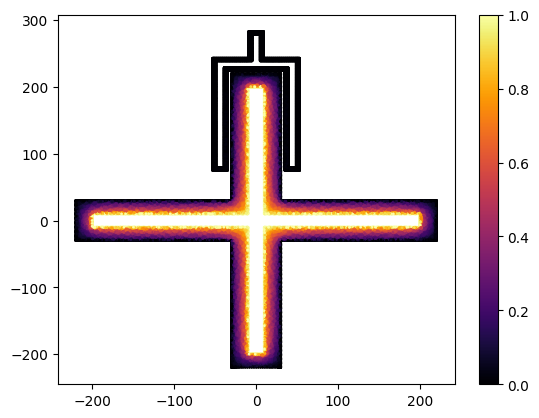

In [10]:
xmon_simulation.plot_field(field="V",index=1)

pyPalace has some built-in extraction tools for common simulation deliverables

In [11]:
capacitance_matrix = xmon_simulation.get_capacitance_matrix()

get_capacitance_matrix() takes the attribute names from the mesh file itself to name the columns/rows other than ground

In [12]:
capacitance_matrix

,cross,claw_connector_arm,ground
cross,1.104549e-13,-4.129382e-15,-1.063255e-13
claw_connector_arm,-4.129382e-15,8.393997e-14,-7.981059e-14
ground,-1.063255e-13,-7.981059e-14,0.000000e+00


# Lumped Oscillator Analysis to extract Hamiltonian parameters

### Calculate $C_\Sigma$ and choose $L_J$ for LOM analysis

We choose an Josephson junction inductance, $L_J = 14$ nH

In [13]:
from pypalace.analysis import LOM

In [14]:
C_Sigma = LOM.calculate_C_Sigma(capacitance_matrix,topology="grounded") # total effective capacitance in Farads
LJ = 14e-09 # 14 nH 

In [15]:
Hamiltonian_params = LOM.get_qubit_Hamiltonian_parameters(C_Sigma,LJ)
Hamiltonian_params

{'frequency_GHz': 3.863284787296769, 'anharmonicity_MHz': -196.952333483423}

## Complete Hamiltonian parameters for a coupled resonator-qubit system

Presume we know this qubit is coupled to a resonator with **$f_r$ = 7 GHz**, this could be extracted via pyPalace by simulating the given resonator with an eigenmode or driven simulation (see Example01 or Example03, respectively). 

Using this known resonator frequency we can also calculate the coupling stength, $g$, and the dispersive shift, $\chi$, of the coupled system.

In [16]:
f_r = 7 * 1e9 # resonator with frequency 7 GHz
C_r = LOM.calculate_C_r(f_r,m=2) # calculate resonator capacitance, m = 2 means we have a quarter-wavelength resonator

f_q = Hamiltonian_params["frequency_GHz"]*1e9 # convert to Hz
alpha = Hamiltonian_params["anharmonicity_MHz"]*1e6 # convert to Hz

# calculate g 
g = LOM.calculate_coupling_strength(capacitance_matrix,LJ,f_r,C_r,topology="grounded")

# calculate chi
chi = LOM.calculate_dispersive_shift(f_q,f_r,alpha,g)

In [17]:
print("Resonator-qubit system Hamiltonian Parameters")
print("---------------------------------------------")
print("              Qubit Parameters               ")
print(f"qubit frequency = {Hamiltonian_params['frequency_GHz']:.2f} GHz")
print(f"qubit anharmonicity = {Hamiltonian_params['anharmonicity_MHz']:.2f} MHz")
print("---------------------------------------------")
print("              Coupled Parameters             ")
print(f"resonator-qubit coupling stength = {g/1e6:.2f} MHz")
print(f"resonator dispersive shift = {chi/1e3:.2f} kHz")

Resonator-qubit system Hamiltonian Parameters
---------------------------------------------
              Qubit Parameters               
qubit frequency = 3.86 GHz
qubit anharmonicity = -196.95 MHz
---------------------------------------------
              Coupled Parameters             
resonator-qubit coupling stength = 39.13 MHz
resonator dispersive shift = -62.87 kHz
